# Introduccion


## Laboratorio N°3

*   Asignatura: Computacion paralela y distribuida
*   Alumno: Elliot Ankatu acevedo
*   Fecha: 18/04/2026
*   Seccion: 412
*   Entorno: Google Colab

# Objetivo
El objetivo de este laboratorio es comparar experimentalmente las estrategias de concurrencia 
disponibles en Python: ejecución secuencial, hilos (ThreadPoolExecutor), procesos (ProcessPoolExecutor) 
y programación asíncrona (asyncio), evaluando su comportamiento ante distintos tipos de carga 
(CPU-bound, I/O-bound y mixta) y distintos tamaños de entrada, con el fin de determinar cuándo 
cada estrategia es apropiada y cuándo no lo es.

# Librerias

In [15]:
import platform
import sys
import time
import multiprocessing
import asyncio
import numpy as np
import math
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

In [3]:

print("=== Registro del entorno ===")
print(f"Python: {sys.version}")
print(f"Sistema operativo: {platform.system()} {platform.release()}")
print(f"Procesador: {platform.processor()}")

=== Registro del entorno ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sistema operativo: Linux 6.6.113+
Procesador: x86_64


# Desafío 1: Distinguir experimentalmente entre carga CPU-bound e I/O-bound

##### 1. a) Caso CPU-bound y evaluación con hilos

En esta primera parte, cada grupo debe diseñar una tarea dominada por cómputo. No basta con
construir una función corta o trivial: debe tratarse de una tarea cuyo tiempo de ejecución dependa
principalmente del uso del procesador. Puede consistir, por ejemplo, en acumulaciones numéricas in-
tensivas, cálculos iterativos, transformaciones matemáticas repetidas o procesamiento deliberadamente
costoso sobre bloques de datos.

La tarea debe compararse en dos modalidades:

*   ejecución secuencial;

*   ejecución mediante hilos, usando threading o ThreadPoolExecutor.

La meta no es “demostrar” una aceleración, sino observar si la estrategia basada en hilos mejora o no
el comportamiento y explicar por qué el resultado es coherente con el rol del GIL.

Se espera que el grupo:
1. defina una tarea CPU-bound propia;
2. seleccione al menos dos o tres tamaños de entrada;
3. mida tiempos con criterio;
4. compare la variante secuencial y la variante con hilos;
5. interprete el resultado usando los conceptos revisados en clases.

#### Funciones

In [22]:
def CPU_work(x):
    suma = 0.0
    for i in range(1, x):
        suma += (i**2) + math.log(i)*i - (math.sin(i**2))
    return suma

data_tamaño = [200_000, 500_000, 800_000]
data_tamaño2 = [500_000, 1_000_000, 2_000_000]

p = [1,2,4]

def secuencial(n):
    start_sec = time.perf_counter()
    for i in n:
        CPU_work(i)
    stop_sec = time.perf_counter()
    return stop_sec - start_sec

def threads(n, p):
    start_t = time.perf_counter()
    with ThreadPoolExecutor(max_workers=p) as executer:
        executer.map(CPU_work, n)
    stop_t = time.perf_counter()
    return stop_t - start_t

##### tamaño de datos pequeño

In [20]:
t_secuencial = secuencial(data_tamaño)
print(f'secuencial: {t_secuencial:.4f}[s]')

secuencial: 1.2349[s]


In [24]:
for workers in p:
    t_threads = threads(data_tamaño, workers)
    print(f"Threads (p: {workers}): { t_threads:.4f} [s]")

Threads (p: 1): 0.4370 [s]
Threads (p: 2): 0.4268 [s]
Threads (p: 4): 0.4333 [s]


#### tamaño de datos grande

In [23]:
t_secuencial = secuencial(data_tamaño2)
print(f'secuencial: {t_secuencial:.4f}[s]')

secuencial: 0.9911[s]


In [25]:
for workers in p:
    t_threads = threads(data_tamaño2, workers)
    print(f"Threads (p: {workers}): { t_threads:.4f} [s]")

Threads (p: 1): 0.9821 [s]
Threads (p: 2): 0.9944 [s]
Threads (p: 4): 1.0090 [s]


#### Resultados (pc y colab)

**Nota:** Los outputs visibles en el notebook corresponden a ejecuciones en Google Colab. 
Las tablas y análisis utilizan los tiempos obtenidos en PC local para mayor consistencia.

##### Colab 

**Dataset pequeño** 

| Estrategia   | Tamaños de entrada        | Tiempo (s) |
|--------------|---------------------------|------------|
| Secuencial   | 200.000, 500.000, 800.000 | 1.2349     |
| Threads p=1  | 200.000, 500.000, 800.000 | 0.4370     |
| Threads p=2  | 200.000, 500.000, 800.000 | 0.4268     |
| Threads p=4  | 200.000, 500.000, 800.000 | 0.4333     |

**Dataset grande** 

| Estrategia   | Tamaños de entrada            | Tiempo (s) |
|--------------|-------------------------------|------------|
| Secuencial   | 500.000, 1.000.000, 2.000.000 | 0.9911     |
| Threads p=1  | 500.000, 1.000.000, 2.000.000 | 0.9821     |
| Threads p=2  | 500.000, 1.000.000, 2.000.000 | 0.9944     |
| Threads p=4  | 500.000, 1.000.000, 2.000.000 | 1.0090     |

##### PC 

**Dataset pequeño**

| Estrategia   | Tamaños de entrada        | Tiempo (s) |
|--------------|---------------------------|------------|
| Secuencial   | 200.000, 500.000, 800.000 | 0.4462     |
| Threads p=1  | 200.000, 500.000, 800.000 | 0.4728     |
| Threads p=2  | 200.000, 500.000, 800.000 | 0.4601     |
| Threads p=4  | 200.000, 500.000, 800.000 | 0.4460     |

**Dataset grande**

| Estrategia   | Tamaños de entrada              | Tiempo (s) |
|--------------|---------------------------------|------------|
| Secuencial   | 500.000, 1.000.000, 2.000.000   | 1.0301     |
| Threads p=1  | 500.000, 1.000.000, 2.000.000   | 1.0296     |
| Threads p=2  | 500.000, 1.000.000, 2.000.000   | 1.0625     |
| Threads p=4  | 500.000, 1.000.000, 2.000.000   | 1.0377     |   

##### Analisis

El GIL en CPython permite que solo un hilo ejecute bytecode Python a la vez, por lo que en tareas de puro cómputo como las CPU-bound no logran paralelismo real.

Al observar los resultados se puede ver que los tiempos no necesariamente mejoran con respecto a la secuencial, esto se debe a GIL, ya que solo permite que un hilo se ejecute a la vez, por lo que incluso si se hacen pruebas en un entorno distinto a Colab, como un PC local, no mejorará, ya que al limitar los hilos, aunque se quieran colocar 4 hilos, solo funcionarán uno a la vez. Además, crear y coordinar hilos tiene un costo propio, por lo que puede aumentar el tiempo. Esto se puede notar especialmente en tareas tipo CPU-bound porque al ser tareas puramente de bytecode, el GIL nunca se libera, causando que el paralelismo no ocurra.
Esto se refleja en los resultados, donde con dataset pequeño p=2 obtuvo 0.4601 s frente al secuencial de 0.4462 s, y con dataset grande los cuatro estrategias obtuvieron tiempos prácticamente iguales entre 1.03 s y 1.06 segundos.

##### 1. b) Caso I/O-bound y evaluación con hilos

En esta segunda parte, el grupo debe construir una tarea donde el tiempo esté dominado por espera,
latencia o acceso a recursos. Puede simularse mediante pausas controladas, lectura de archivos, pro-
cesamiento de múltiples operaciones que incluyan espera o cualquier situación análoga técnicamente
defendible.

La comparación debe hacerse nuevamente entre:

1. ejecución secuencial;
2. ejecución con hilos.

El objetivo es que el grupo observe si el comportamiento cambia respecto del caso anterior y explique
por qué.
Se espera que el equipo:
1. diseñe una tarea I/O-bound propia;
2. justifique por qué la considera de ese tipo;
3. compare tiempos con y sin hilos;
4. discuta las diferencias respecto del caso CPU-bound.

#### Funciones

In [12]:
io_size = [50, 100, 500]
p = [1,2,4]
def IO_bound(n):
    time.sleep(0.01)
    return (n**2) + 1

def secuencial_io(n):
    start_IO_sec = time.perf_counter()
    for i in n:
        IO_bound(i)
    final_IO_sec = time.perf_counter()

    return final_IO_sec - start_IO_sec

def threads_io(n, p = 4):
    start_IO_threads = time.perf_counter()
    with ThreadPoolExecutor(max_workers=p) as ex_io:
        ex_io.map(IO_bound, n)
    final_IO_threads = time.perf_counter()
    return final_IO_threads - start_IO_threads

In [13]:
for i in io_size:
    data_io = list(range(i))
    t_io_sec = secuencial_io(data_io)
    print(f"Tamaño {i} | Secuencial: {t_io_sec:.4f}s")
    for j in p:
        t_io_threads = threads_io(data_io, j)
        print(f"Tamaño {i} | Threads p={j}: {t_io_threads:.4f}s")

Tamaño 50 | Secuencial: 0.5059s
Tamaño 50 | Threads p=1: 0.5108s
Tamaño 50 | Threads p=2: 0.2546s
Tamaño 50 | Threads p=4: 0.1324s
Tamaño 100 | Secuencial: 1.0116s
Tamaño 100 | Threads p=1: 1.0159s
Tamaño 100 | Threads p=2: 0.5085s
Tamaño 100 | Threads p=4: 0.2545s
Tamaño 500 | Secuencial: 5.0592s
Tamaño 500 | Threads p=1: 5.0770s
Tamaño 500 | Threads p=2: 2.5419s
Tamaño 500 | Threads p=4: 1.2743s


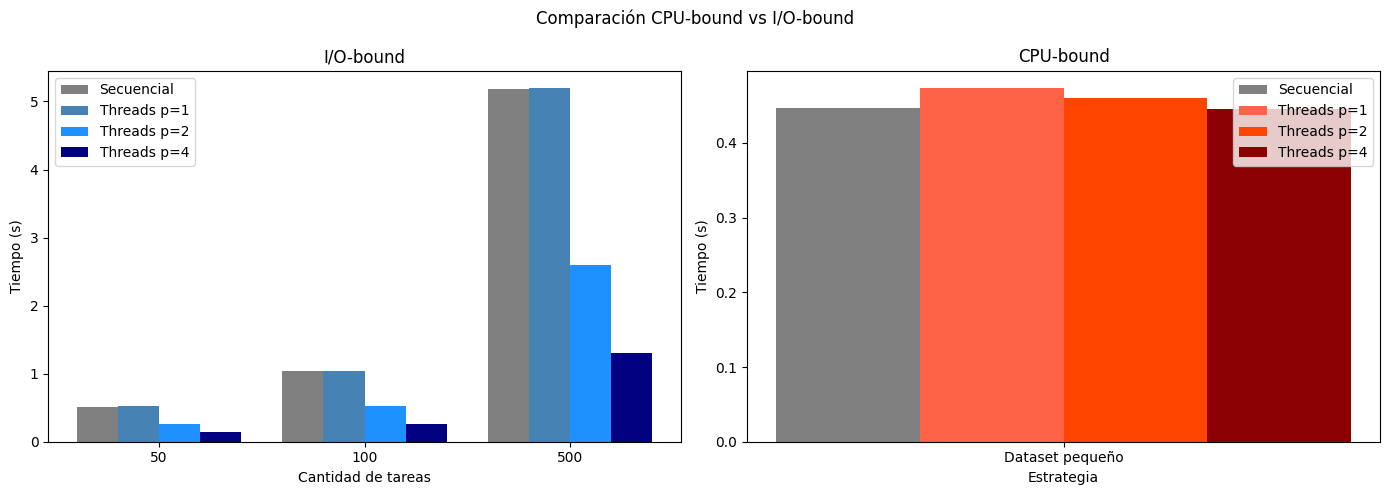

In [18]:
tamaños = [50, 100, 500]
sec_io =    [0.5156, 1.0368, 5.1813]
thr_io_p1 = [0.5206, 1.0422, 5.1904]
thr_io_p2 = [0.2612, 0.5194, 2.5934]
thr_io_p4 = [0.1365, 0.2615, 1.3009]

sec_cpu = [0.4462, 0.4462, 0.4462]  # mismo valor, referencia
thr_cpu_p1 = [0.4728, 0.4728, 0.4728]
thr_cpu_p2 = [0.4601, 0.4601, 0.4601]
thr_cpu_p4 = [0.4460, 0.4460, 0.4460]

x = np.arange(len(tamaños))
ancho = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# I/O-bound
ax1.bar(x - 1.5*ancho, sec_io,    ancho, label="Secuencial", color="gray")
ax1.bar(x - 0.5*ancho, thr_io_p1, ancho, label="Threads p=1", color="steelblue")
ax1.bar(x + 0.5*ancho, thr_io_p2, ancho, label="Threads p=2", color="dodgerblue")
ax1.bar(x + 1.5*ancho, thr_io_p4, ancho, label="Threads p=4", color="navy")
ax1.set_title("I/O-bound")
ax1.set_ylabel("Tiempo (s)")
ax1.set_xlabel("Cantidad de tareas")
ax1.set_xticks(x)
ax1.set_xticklabels(tamaños)
ax1.legend()

# CPU-bound
cpu_labels = ["Dataset pequeño"]
ax2.bar(0 - 1.5*ancho, 0.4462, ancho, label="Secuencial",  color="gray")
ax2.bar(0 - 0.5*ancho, 0.4728, ancho, label="Threads p=1", color="tomato")
ax2.bar(0 + 0.5*ancho, 0.4601, ancho, label="Threads p=2", color="orangered")
ax2.bar(0 + 1.5*ancho, 0.4460, ancho, label="Threads p=4", color="darkred")
ax2.set_title("CPU-bound")
ax2.set_ylabel("Tiempo (s)")
ax2.set_xlabel("Estrategia")
ax2.set_xticks([0])
ax2.set_xticklabels(["Dataset pequeño"])
ax2.legend()

plt.suptitle("Comparación CPU-bound vs I/O-bound")
plt.tight_layout()
plt.show()

##### Analisis

los resultados muestran una gran mejoria en comparacion a CPU-bound, ya que GIL se libera en los momentos que time.sleep() hace esperar a un hilo, gracias a esto se puede paralelizar los procesos en varios hilos permitiendo que el tiempo mejore al tener mas hilos trabajando, en la siguiente tabla puede visualizarse que en la primera iteracion p = 1 fue practicamente igual a la secuencial, esto se debe a que al solo haber un hilo no hay paralelismo real, tomando como ejemplo tamaño 500, el resultado con p = 1 es similar al resultado secuencial de 5.1813 [s], pero al aumentar los hilos se puede ver que el tiempo va disminuyendo p = 4 el tiempo disminuye a tan solo 1.3009 [s]
| Tamaño | Estrategia   | Tiempo (s) |
|--------|--------------|------------|
| 50     | Secuencial   | 0.5156     |
| 50     | Threads p=1  | 0.5206     |
| 50     | Threads p=2  | 0.2612     |
| 50     | Threads p=4  | 0.1365     |
| 100    | Secuencial   | 1.0368     |
| 100    | Threads p=1  | 1.0422     |
| 100    | Threads p=2  | 0.5194     |
| 100    | Threads p=4  | 0.2615     |
| 500    | Secuencial   | 5.1813     |
| 500    | Threads p=1  | 5.1904     |
| 500    | Threads p=2  | 2.5934     |
| 500    | Threads p=4  | 1.3009     |

#### Analisis comparativo

**CPU-bound (dataset pequeño)**

| Estrategia   | Tiempo (s) | Speedup | Eficiencia |
|--------------|------------|---------|------------|
| Secuencial   | 0.4462     | 1.00    | -          |
| Threads p=1  | 0.4728     | 0.94    | 0.94       |
| Threads p=2  | 0.4601     | 0.97    | 0.48       |
| Threads p=4  | 0.4460     | 1.00    | 0.25       |

**I/O-bound (tamaño 500)**

| Estrategia   | Tiempo (s) | Speedup | Eficiencia |
|--------------|------------|---------|------------|
| Secuencial   | 5.1813     | 1.00    | -          |
| Threads p=1  | 5.1904     | 1.00    | 1.00       |
| Threads p=2  | 2.5934     | 2.00    | 1.00       |
| Threads p=4  | 1.3009     | 3.98    | 0.99       |

CPU-bound los hilos no mejoraron basicamente nada dando un Speedup : $S(p) ≈ 1 $, en cambio en I/O-bound los hilos mejoraron de manera considerable con $ S(p) ≈ 4.0$
con respecto a las eficiencia CPU-bound tan solo obtuvo $E(p) < 0.5$ en casi todas las iteraciones incluso con mayor cantidad de hilos empeoraba consiguiendo que con 4 hilos solo consiguiera $E(p)≈ 0.25 $ que significa que el 25% del esfuerzo fue util, el resto fue overhead, en cambio I/O-bound tomando p = 4 tuvo una eficiencia $E(p) ≈ 0.99 $ significando que casi todo el esfuerzo fue util.
cabe mencionar que los tiempos absolutos entre un metodo y el otro no son directamente comparables, ya que los tamaños de entrada representan conceptos distintos - En CPU-bound son iteraciones internas de computo mientras que en I/O-bound son cantidades de tareas con espera, la comparacion esta enfocada en el comportamiento que ambos metodos muestran.

Conclusion de analisis

los hilos no son siempre buenos o malos, siempre dependera del tipo de carga , para CPU-bound en python con Cpython, no son la herramienta correcta, en cambio para I/O-bound si lo son.

# Desafío 2: Comparar hilos y procesos en una tarea intensiva

Este desafío eleva la exigencia experimental. Ya no basta con comparar un solo enfoque con el secuen-
cial, sino que se debe contrastar explícitamente el comportamiento de:
1. ejecución secuencial;
2. ejecución con hilos;
3. ejecución con procesos.

Aquí el grupo debe construir una tarea CPU-bound suficientemente sustantiva como para que la
comparación tenga sentido. Si el caso es demasiado pequeño, lo que se medirá será principalmente
overhead y no comportamiento concurrente relevante.

#### 2.a) Diseño e implementación del benchmark comparativo

Cada grupo debe proponer una tarea de cómputo intensivo dividida en unidades relativamente independientes. La tarea puede consistir, por ejemplo, en aplicar una función costosa a múltiples bloques,
calcular resultados sobre diferentes entradas, procesar lotes numéricos o cualquier estructura equivalente.
Se exige:
1. definición clara de la tarea;
2. justificación de por qué se trata de una carga CPU-bound;
3. comparación entre secuencial, hilos y procesos;
4. medición con al menos dos configuraciones de tamaño

##### Funciones

para un analisis consistente se reutilizaran las funciones del desafio anterior y solo se agregara la funcion de procesos

#### Descripcion de la tarea

CPU_work es una funcion que itera desde 1 hasta x, sumando una compleja ecuacion (i²) + log(i)·i - sin(i²)
es una carga tipo CPU-bound, ya que es calculo puro y el tiempo depende del procesador
cada elemento se procesa de forma independiente ya que por ejemplo CPU_work(200_000) no depende de CPU_work(500_000)

In [19]:
def CPU_work(x):
    suma = 0.0
    for i in range(1, x):
        suma += (i**2) + math.log(i)*i - (math.sin(i**2))
    return suma

data_tamaño = [200_000, 500_000, 800_000]
data_tamaño2 = [500_000, 1_000_000, 2_000_000]

p = [1,2,4]

def secuencial(n):
    start_sec = time.perf_counter()
    for i in n:
        CPU_work(i)
    stop_sec = time.perf_counter()
    return stop_sec - start_sec

def threads(n, p):
    start_t = time.perf_counter()
    with ThreadPoolExecutor(max_workers=p) as executer:
        executer.map(CPU_work, n)
    stop_t = time.perf_counter()
    return stop_t - start_t

def process(n, p):
    start_t = time.perf_counter()
    with ProcessPoolExecutor(max_workers=p) as process:
        process.map(CPU_work, n)
    stop_t = time.perf_counter()
    return stop_t - start_t

In [20]:
t_sec = secuencial(data_tamaño)
print(f"Secuencial: {t_sec:.4f}s")

for workers in p:
    t_thr = threads(data_tamaño, workers)
    t_proc = process(data_tamaño, workers)
    print(f"Threads (p={workers}): {t_thr:.4f}s | Procesos (p={workers}): {t_proc:.4f}s")

Secuencial: 0.7004s
Threads (p=1): 0.6881s | Procesos (p=1): 0.6979s
Threads (p=2): 0.7065s | Procesos (p=2): 0.6888s
Threads (p=4): 0.7164s | Procesos (p=4): 0.6985s


In [21]:
t_sec = secuencial(data_tamaño2)
print(f"Secuencial: {t_sec:.4f}s")

for workers in p:
    t_thr = threads(data_tamaño2, workers)
    t_proc = process(data_tamaño2, workers)
    print(f"Threads (p={workers}): {t_thr:.4f}s | Procesos (p={workers}): {t_proc:.4f}s")

Secuencial: 1.5986s
Threads (p=1): 2.0655s | Procesos (p=1): 2.3426s
Threads (p=2): 1.6591s | Procesos (p=2): 1.5946s
Threads (p=4): 1.6407s | Procesos (p=4): 1.5773s


**Dataset pequeño [200k, 500k, 800k] — PC local**

| Estrategia      | Tiempo (s) | Speedup | Eficiencia |
|-----------------|------------|---------|------------|
| Secuencial      | 0.4211     | 1.00    | -          |
| Threads p=1     | 0.4291     | 0.98    | 0.98       |
| Threads p=2     | 0.4282     | 0.98    | 0.49       |
| Threads p=4     | 0.4281     | 0.98    | 0.25       |
| Procesos p=1    | 0.7292     | 0.58    | 0.58       |
| Procesos p=2    | 0.5739     | 0.73    | 0.37       |
| Procesos p=4    | 0.6432     | 0.65    | 0.16       |

**Dataset grande [500k, 1M, 2M] — PC local**

| Estrategia      | Tiempo (s) | Speedup | Eficiencia |
|-----------------|------------|---------|------------|
| Secuencial      | 0.9836     | 1.00    | -          |
| Threads p=1     | 0.9841     | 1.00    | 1.00       |
| Threads p=2     | 0.9911     | 0.99    | 0.50       |
| Threads p=4     | 0.9875     | 1.00    | 0.25       |
| Procesos p=1    | 1.2659     | 0.78    | 0.78       |
| Procesos p=2    | 0.9817     | 1.00    | 0.50       |
| Procesos p=4    | 0.8950     | 1.10    | 0.27       |

**Dataset pequeño [200k, 500k, 800k] — Google Colab**

| Estrategia      | Tiempo (s) | Speedup | Eficiencia |
|-----------------|------------|---------|------------|
| Secuencial      | 0.7004     | 1.00    | -          |
| Threads p=1     | 0.6881     | 1.02    | 1.02       |
| Threads p=2     | 0.7065     | 0.99    | 0.50       |
| Threads p=4     | 0.7164     | 0.98    | 0.24       |
| Procesos p=1    | 0.6979     | 1.00    | 1.00       |
| Procesos p=2    | 0.6888     | 1.02    | 0.51       |
| Procesos p=4    | 0.6985     | 1.00    | 0.25       |

**Dataset grande [500k, 1M, 2M] — Google Colab**

| Estrategia      | Tiempo (s) | Speedup | Eficiencia |
|-----------------|------------|---------|------------|
| Secuencial      | 1.5986     | 1.00    | -          |
| Threads p=1     | 2.0655     | 0.77    | 0.77       |
| Threads p=2     | 1.6591     | 0.96    | 0.48       |
| Threads p=4     | 1.6407     | 0.97    | 0.24       |
| Procesos p=1    | 2.3426     | 0.68    | 0.68       |
| Procesos p=2    | 1.5946     | 1.00    | 0.50       |
| Procesos p=4    | 1.5773     | 1.01    | 0.25       |

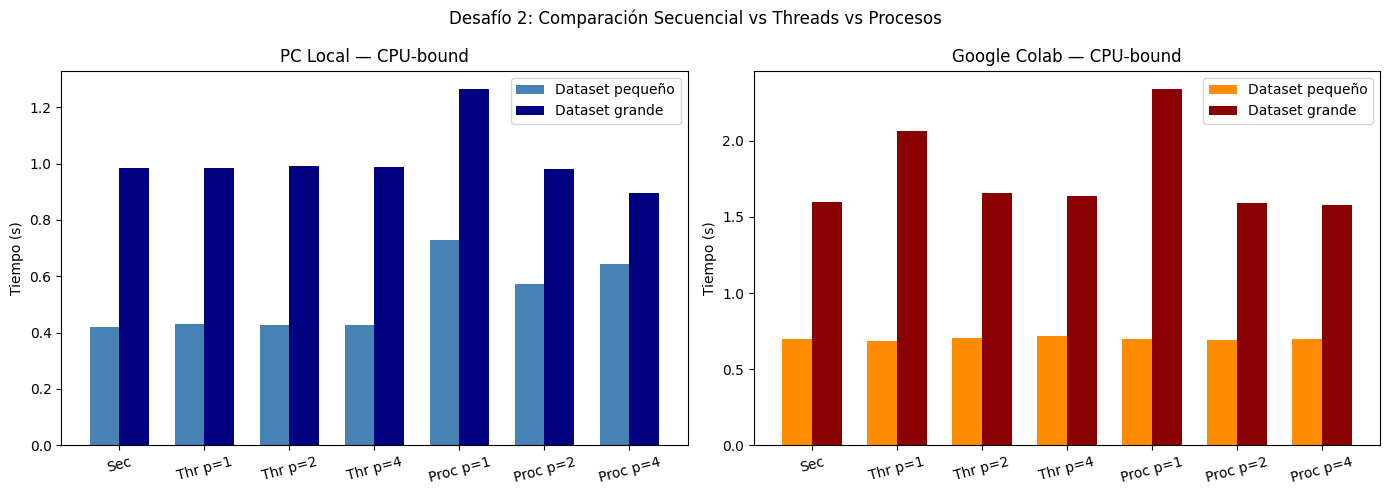

In [33]:
estrategias = ["Sec", "Thr p=1", "Thr p=2", "Thr p=4", "Proc p=1", "Proc p=2", "Proc p=4"]
x = np.arange(len(estrategias))
ancho = 0.35

# Datos PC local
pc_pequeño = [0.4211, 0.4291, 0.4282, 0.4281, 0.7292, 0.5739, 0.6432]
pc_grande =  [0.9836, 0.9841, 0.9911, 0.9875, 1.2659, 0.9817, 0.8950]

# Datos Colab
colab_pequeño = [0.7004, 0.6881, 0.7065, 0.7164, 0.6979, 0.6888, 0.6985]
colab_grande =  [1.5986, 2.0655, 1.6591, 1.6407, 2.3426, 1.5946, 1.5773]

# Grafico PC local
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x - ancho/2, pc_pequeño, ancho, label="Dataset pequeño", color="steelblue")
ax1.bar(x + ancho/2, pc_grande,  ancho, label="Dataset grande",  color="navy")
ax1.set_title("PC Local — CPU-bound")
ax1.set_ylabel("Tiempo (s)")
ax1.set_xticks(x)
ax1.set_xticklabels(estrategias, rotation=15)
ax1.legend()

ax2.bar(x - ancho/2, colab_pequeño, ancho, label="Dataset pequeño", color="darkorange")
ax2.bar(x + ancho/2, colab_grande,  ancho, label="Dataset grande",  color="darkred")
ax2.set_title("Google Colab — CPU-bound")
ax2.set_ylabel("Tiempo (s)")
ax2.set_xticks(x)
ax2.set_xticklabels(estrategias, rotation=15)
ax2.legend()

plt.suptitle("Desafío 2: Comparación Secuencial vs Threads vs Procesos")
plt.tight_layout()
plt.show()

#### 2.b) Interpretación del comportamiento observado

Con base en los resultados obtenidos, el grupo debe responder técnicamente preguntas como las si-
guientes:
* ¿Qué estrategia fue más conveniente y en qué condiciones?
* ¿Los procesos mejoraron frente a los hilos?
* ¿Qué costos adicionales aparecieron al usar procesos?
* ¿Por qué una mayor cantidad de workers no garantiza speedup lineal?
* ¿Qué relación existe entre granularidad de la tarea y overhead?.

Esta parte no debe resolverse con observaciones superficiales. Se espera una explicación apoyada en
conceptos como GIL, serialización, creación de procesos, coordinación, costo fijo y tamaño del problema.

#### ¿Qué estrategia fue más conveniente y en qué condiciones?
Cada estrategia tiene su punto fuerte, por ejemplo en casos como I/O-bound conviene mas usar threads que secuencial, ya que al usar time.sleep(), se libera GIL lo que permite la paralelizacion, por lo tanto dando mejores tiempo, speedup y eficiencia, por otro lado en CPU-bound, al ser todo computo interno sin esperas, no se logra liberar GIL, por lo que entre secuencial y threads no hay diferencias, para simplificar el codigo es mas conveniente usar la forma secuencial.
#### ¿Los procesos mejoraron frente a los hilos?
los procesos si mejoran con respectos a los hilos, pero con matices importantes, si los datos son pequeños los procesos pueden resultar ser mas lentos que threads y secuencial, pero cuando empiezan a crecer el tamaños de los datos, se puede evidenciar que los tiempos, speedup y eficiencia mejoran con respecto a threads e secuencial. Esto ocurre debido a que cada proceso tiene su propio GIL, permitiendo paralelismo real en cada nucleo.
#### ¿Qué costos adicionales aparecieron al usar procesos?
crear un proceso implica iniciar un intérprete Python independiente, asignar memoria propia y serializar los datos mediante IPC, lo que genera un costo fijo que existe independiente del tamaño del problema. Por eso con datos pequeños el overhead domina y los procesos pierden frente al secuencial.
#### ¿Por qué una mayor cantidad de workers no garantiza speedup lineal?
A mayor cantidad de workers, mayor es el overhead de coordinación entre procesos. Además, si los núcleos físicos disponibles son limitados como en Colab, los procesos extra compiten entre sí en lugar de ejecutarse en paralelo, lo que explica que en ese entorno ninguna estrategia mejorara significativamente
#### ¿Qué relación existe entre granularidad de la tarea y overhead?.
La relación entre granularidad y overhead es fundamental cuando la tarea por proceso es pequeña, el costo fijo de crearlo domina. Cuando la tarea es grande, ese costo se amortiza y el paralelismo real de ProcessPoolExecutor, se vuelve ventajoso. ProcessPoolExecutor usa multiprocessing de forma interna

# Desafío 3: Evaluar asyncio en un escenario mixto y formular una recomendación técnica

#### 3. a) Diseño de un caso mixto y comparación con asyncio
El grupo debe diseñar un escenario mixto. Por ejemplo, una tarea que simule una espera o consulta y
luego aplique una transformación local, o una colección de tareas que combinen una fase de latencia
con un procesamiento posterior no demasiado pesado.
Se debe implementar, como mínimo:
1. una versión secuencial;
2. una versión asíncrona mediante asyncio.

Si el grupo considera pertinente incorporar además una variante con hilos para enriquecer el análisis,
puede hacerlo.

Se espera que el equipo:

1. describa claramente el escenario propuesto;
2. explicite sus supuestos;
3. implemente la versión secuencial y la versión asíncrona;
4. mida tiempos;
5. discuta qué parte del comportamiento observado se explica por espera y qué parte por cómputo.

#### Funciones

In [28]:
def computo_s(n):
    time.sleep(0.01)
    return math.log(n) + 4*math.sin(n**2) + (n-1)**2

def mixta_sec(n):
    start_m = time.perf_counter()
    sum = 0.0
    for i in n:
        sum += computo_s(i)
    return time.perf_counter() - start_m

async def computo_a(n):
    await asyncio.sleep(0.01)
    return math.log(n) + 4*math.sin(n**2) + (n-1)**2

async def mixta_async(n):
    tareas = [computo_a(i) for i in n]
    return await asyncio.gather(*tareas)
    

In [ ]:
import nest_asyncio
data_mixta = list(range(1, 101))

nest_asyncio.apply()

start_async = time.perf_counter()
resultado = await mixta_async(data_mixta)
final_async = time.perf_counter()
t_async = final_async - start_async

t_sec = mixta_sec(data_mixta)
print(f"Secuencial: {t_sec:.4f}s")
print(f"Async:      {t_async:.4f}s")

Secuencial: 1.0151s
Async:      0.0171s


##### Descripción del escenario
Se diseñó un escenario mixto donde cada tarea simula una consulta externa mediante time.sleep(0.01) 
y luego aplica una transformación matemática: log(n) + 4·sin(n²) + (n-1)². 
Ejecutandose un total de 100 tareas.

##### Supuestos
- Cada tarea es independiente entre sí
- El sleep simula la latencia de una consulta externa 
- El cómputo posterior es liviano en comparación con la espera

##### Tiempos obtenidos
| Estrategia | Tareas | Tiempo (s) | Speedup |
|------------|--------|------------|---------|
| Secuencial | 100    | 1.0151     | 1.00    |
| Async      | 100    | 0.0171     | 59.36   |

##### Espera vs cómputo
El tiempo secuencial de ~1.0s se explica casi completamente por la espera — 100 tareas × 0.01s 
ejecutadas una por una. En cambio asyncio lanzó las 100 corrutinas simultáneamente mediante el 
event loop, permitiendo que todas esperaran al mismo tiempo. La pequeña diferencia entre el tiempo 
teórico (0.01s) y el obtenido (0.017s) se explica por el cómputo matemático y el overhead del 
event loop al coordinar las corrutinas.

#### 3.b) Recomendación técnica final

A partir del conjunto completo de experimentos realizados, cada grupo debe redactar una recomendación final de entre 300 y 500 palabras que responda a la siguiente pregunta:
Dado un problema nuevo en Python, ¿qué criterios utilizaría el grupo para decidir entre
una solución secuencial, una basada en hilos, una basada en procesos o una asíncrona?

La respuesta debe integrar al menos:
* naturaleza de la carga;
* tamaño del problema;
* overhead de coordinación;
* facilidad de implementación;
* restricciones del entorno;
* límites observados en los experimentos;
* riesgos de interpretar mal un benchmark.

No se evaluará positivamente una conclusión genérica o meramente declarativa. La recomendación
debe apoyarse en la evidencia generada por el propio grupo.

Para decidir entre una solución secuencial, basada en hilos, procesos o asíncrona, el primer criterio 
y más importante es identificar la naturaleza del problema es decir de la carga, quedó demostrado experimentalmente que en tareas CPU-bound, como la función CPU_work que realiza cálculos 
matemáticos intensivos, los hilos no mejoraron el rendimiento debido al GIL de CPython, En cambio, en tareas I/O-bound como la simulación con time.sleep(), los hilos sí lograron mejoras significativas con Speedup de hasta 3.98 y Eficiencia de 0.99 con p=4. Para cargas mixtas, asyncio demostró ser la estrategia más eficiente, obteniendo 
un Speedup de 59.36 frente al secuencial al paralelizar 100 tareas con espera y cómputo liviano.

El segundo criterio es el tamaño del problema. No basta con identificar el tipo de carga — el tamaño 
determina si el overhead de coordinación vale la pena. En el Desafío 2 se observó que con dataset 
pequeño ProcessPoolExecutor fue más lento que el secuencial en todos los casos, debido al costo fijo 
de crear procesos independientes, asignar memoria y serializar datos mediante IPC. Solo con dataset 
grande ProcessPoolExecutor con p=4 logró mejorar al secuencial (0.8950s vs 0.9836s). Por lo tanto, 
para problemas pequeños el secuencial sigue siendo la mejor opción independiente del tipo de carga.

El tercer criterio es la facilidad de implementación. Si los tiempos son aceptables con una solución 
secuencial, no vale la pena agregar complejidad de concurrencia. Threads y ProcessPoolExecutor tienen 
una implementación moderada, mientras que asyncio requiere entender el event loop y el modelo 
async/await. La complejidad adicional solo se justifica cuando hay evidencia experimental de mejora real.

El cuarto criterio son las restricciones del entorno. En los experimentos realizados en Google Colab, 
ninguna estrategia mejoró consistentemente debido a que el entorno limita los núcleos disponibles. 
En cambio en PC local, ProcessPoolExecutor sí mostró mejoras con dataset grande. Esto demuestra que 
una estrategia puede funcionar bien en un entorno y mal en otro, por lo que siempre es necesario 
medir en el entorno real donde correrá el programa.

Finalmente, existe el riesgo de interpretar mal un benchmark. Un problema demasiado pequeño mide 
overhead en lugar de comportamiento concurrente real, como se observó en el Desafío 2 con dataset 
pequeño. Además, entornos compartidos como Colab producen tiempos variables entre ejecuciones, lo 
que puede llevar a conclusiones incorrectas. Por eso es fundamental repetir mediciones, controlar 
variables y no generalizar resultados obtenidos en un solo entorno o tamaño de problema.

En resumen, la decisión debe seguir este orden: primero identificar el tipo de carga, luego evaluar 
el tamaño del problema, considerar el overhead de cada estrategia, tomar en cuenta las restricciones 
del entorno y finalmente verificar que el benchmark esté bien diseñado antes de sacar conclusiones.
